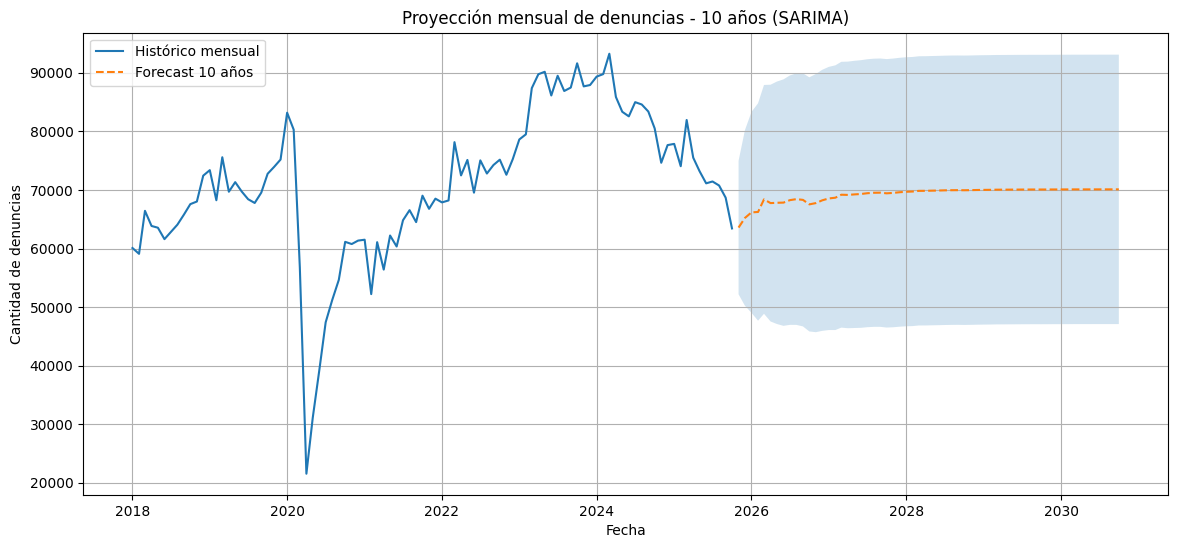

            forecast  lower_ci  upper_ci
2025-11-01  63581.39  52188.03  74974.75
2025-12-01  65220.97  50232.56  80209.38
2026-01-01  66176.52  49031.56  83321.47
2026-02-01  66242.49  47679.60  84805.38
2026-03-01  68396.45  48862.53  87930.38
2026-04-01  67758.45  47544.52  87972.39
2026-05-01  67811.88  47115.22  88508.54
2026-06-01  67842.22  46799.86  88884.59
2026-07-01  68259.11  46967.71  89550.50
2026-08-01  68435.80  46964.28  89907.33
2026-09-01  68306.32  46704.13  89908.50
2026-10-01  67540.97  45843.81  89238.13
2026-11-01  67760.08  45719.38  89800.77
2026-12-01  68231.57  45943.22  90519.92
2027-01-01  68550.72  46083.14  91018.29
2027-02-01  68682.30  46084.68  91279.92
2027-03-01  69189.30  46497.13  91881.47
2027-04-01  69156.37  46395.37  91917.37
2027-05-01  69240.85  46429.69  92052.01
2027-06-01  69310.18  46462.44  92157.92
2027-07-01  69442.97  46568.54  92317.40
2027-08-01  69522.69  46628.77  92416.60
2027-09-01  69538.06  46629.93  92446.20
2027-10-01  6942

In [ ]:
# =========================================
# Proyección de crimen con ARIMA
# Data: denuncias_mensuales.xlsx
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 1) Cargar datos
# -----------------------------
df = pd.read_excel("/Users/karlavega/Proyectos/Colaborativos/Forest_Peru/colapso_con_ubigeo_reniec/denuncias_mensuales.xlsx")

# Crear fecha mensual
df["fecha"] = pd.to_datetime(
    df["ANIO"].astype(str) + "-" + df["MES"].astype(str) + "-01"
)

# Serie mensual total
ts = (
    df.groupby("fecha")["cantidad"]
      .sum()
      .asfreq("MS")
)

# Rellenar posibles meses faltantes
ts = ts.fillna(0)

# -----------------------------
# 2) Modelo SARIMA estacional
# -----------------------------
model = SARIMAX(
    ts,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    trend='c'
)

res = model.fit(disp=False)

# -----------------------------
# 3) Forecast 5 años (60 meses)
# -----------------------------
HORIZON = 60  # 5 años mensuales

forecast = res.get_forecast(steps=HORIZON)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# -----------------------------
# 4) Gráfico
# -----------------------------
plt.figure(figsize=(14,6))

plt.plot(ts.index, ts, label="Histórico mensual")
plt.plot(forecast_mean.index, forecast_mean,
         linestyle="--", label="Forecast 10 años")

plt.fill_between(
    forecast_mean.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.2
)

plt.title("Proyección mensual de denuncias - 10 años (SARIMA)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de denuncias")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5) Tabla resultado
# -----------------------------
forecast_df = pd.DataFrame({
    "forecast": forecast_mean,
    "lower_ci": conf_int.iloc[:,0],
    "upper_ci": conf_int.iloc[:,1]
})

print(forecast_df.round(2))


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'



===== Evaluación Train/Test (últimos 12 meses) =====
Baseline Naïve RMSE:  8,508.46
SARIMA RMSE:          3,522.11
Baseline Naïve MAPE:  10.48%
SARIMA MAPE:          3.64%

===== FORECAST FUTURO (60 meses) =====
            forecast  lower_ci   upper_ci
2025-11-01  63999.06  50456.50   81176.38
2025-12-01  65420.87  48189.26   88814.07
2026-01-01  66307.36  47059.06   93428.52
2026-02-01  66520.20  46171.01   95837.80
2026-03-01  68093.21  46613.50   99470.65
2026-04-01  67748.08  45972.26   99838.29
2026-05-01  67816.60  45760.69  100502.89
2026-06-01  67838.37  45609.47  100900.82
2026-07-01  68130.17  45697.96  101573.66
2026-08-01  68234.70  45698.09  101885.29
2026-09-01  68099.42  45562.06  101784.67
2026-10-01  67439.41  45091.18  100863.70
2026-11-01  67632.61  45061.71  101508.77
2026-12-01  67935.98  45160.78  102196.78
2027-01-01  68139.23  45228.80  102654.58
2027-02-01  68227.21  45243.50  102886.40
2027-03-01  68506.65  45400.22  103372.84
2027-04-01  68492.39  45372.13 

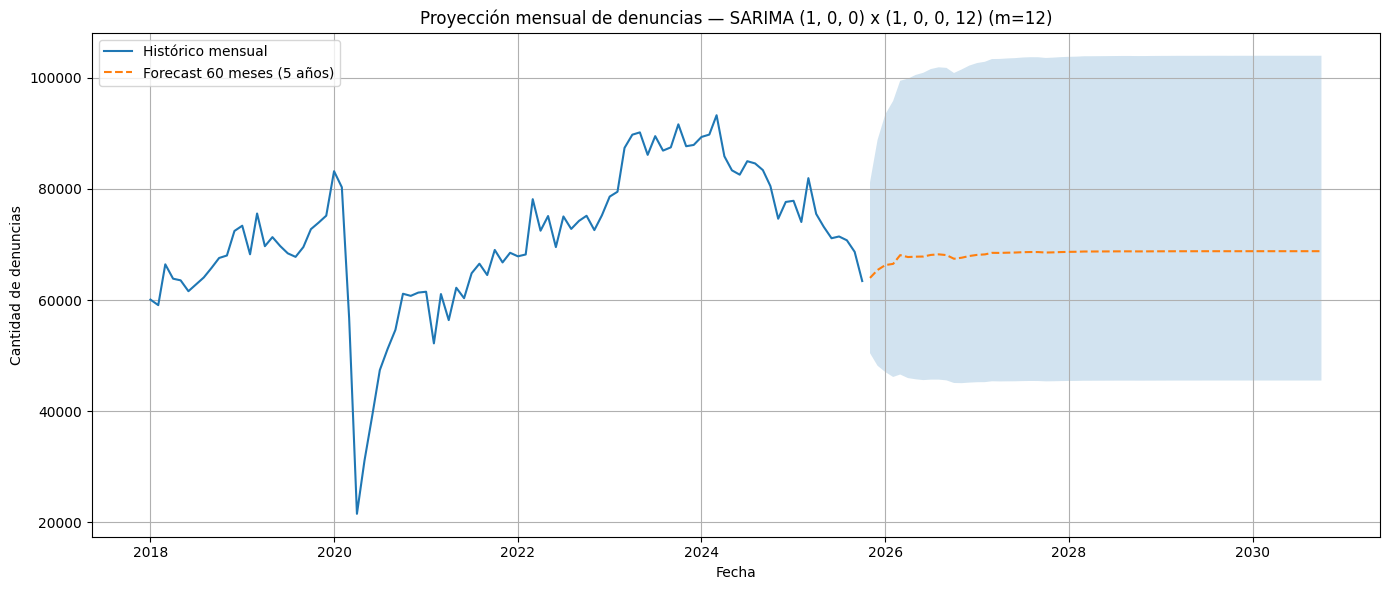

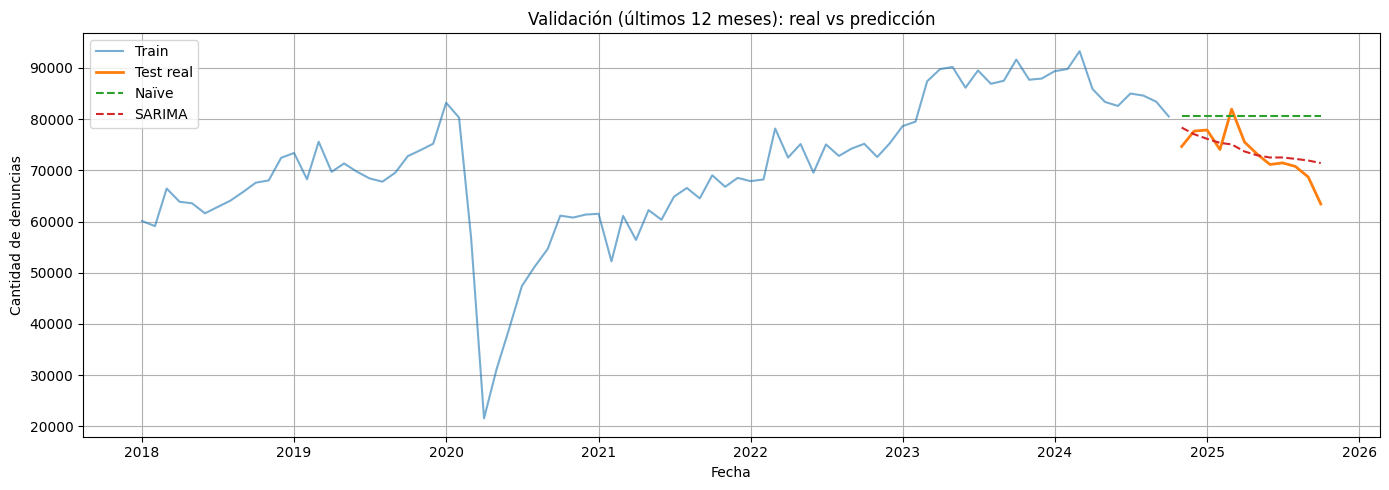


✅ Exportado: forecast_denuncias_5anios.xlsx


In [30]:
# =========================================
# Proyección de denuncias (mensual) — SARIMA estable + validación
# Data: denuncias_mensuales.xlsx
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 0) Config
# -----------------------------
FILE = "/Users/karlavega/Proyectos/Colaborativos/Forest_Peru/colapso_con_ubigeo_reniec/denuncias_mensuales.xlsx"
FREQ = "MS"
H_TEST = 12      # test = últimos 12 meses
HORIZON = 60     # forecast = 60 meses (5 años)
USE_LOG1P = True # recomendado para conteos (evita lower_ci negativos)

# -----------------------------
# 1) Cargar datos + fecha mensual
# -----------------------------
df = pd.read_excel(FILE)

df["fecha"] = pd.to_datetime(
    df["ANIO"].astype(str) + "-" + df["MES"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)
df = df.dropna(subset=["fecha"])

# Serie mensual total
ts = (
    df.groupby("fecha")["cantidad"]
      .sum()
      .asfreq(FREQ)
      .fillna(0.0)
      .astype(float)
)

# -----------------------------
# 2) Split train/test
# -----------------------------
train = ts.iloc[:-H_TEST]
test  = ts.iloc[-H_TEST:]

# Baseline naïve: último valor del train repetido
naive_pred = pd.Series(np.repeat(train.iloc[-1], H_TEST), index=test.index)

# -----------------------------
# 3) (Opcional) Transformación para conteos
# -----------------------------
def inv_log1p(x):
    return np.expm1(x)

if USE_LOG1P:
    y_train = np.log1p(train)
    y_full  = np.log1p(ts)
else:
    y_train = train.copy()
    y_full  = ts.copy()

# -----------------------------
# 4) Ajuste SARIMA (estable)
# -----------------------------
# Tu especificación (muy estable):
# (1,0,0) y estacional (1,0,0,12) con constante
order = (1,0,0)
seasonal_order = (1,0,0,12)

model_train = SARIMAX(
    y_train,
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True
)
res_train = model_train.fit(disp=False)

# Predicción en test
fc_test = res_train.get_forecast(steps=H_TEST)
pred_test = fc_test.predicted_mean

# Volver a escala original
if USE_LOG1P:
    pred_test = inv_log1p(pred_test)

pred_test = pd.Series(pred_test, index=test.index)

# -----------------------------
# 5) Métricas (RMSE, MAPE)
# -----------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, 1.0, y_true)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

rmse_naive  = rmse(test, naive_pred)
rmse_sarima = rmse(test, pred_test)

mape_naive  = mape(test, naive_pred)
mape_sarima = mape(test, pred_test)

print("\n===== Evaluación Train/Test (últimos 12 meses) =====")
print(f"Baseline Naïve RMSE:  {rmse_naive:,.2f}")
print(f"SARIMA RMSE:          {rmse_sarima:,.2f}")
print(f"Baseline Naïve MAPE:  {mape_naive:,.2f}%")
print(f"SARIMA MAPE:          {mape_sarima:,.2f}%")

# -----------------------------
# 6) Ajuste FINAL con toda la serie + Forecast 5 años
# -----------------------------
model_full = SARIMAX(
    y_full,
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True
)
res_full = model_full.fit(disp=False)

forecast = res_full.get_forecast(steps=HORIZON)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Volver a escala original
if USE_LOG1P:
    forecast_mean = inv_log1p(forecast_mean)
    conf_int = inv_log1p(conf_int)

# Tabla forecast + intervalos
forecast_df = pd.DataFrame({
    "forecast": forecast_mean,
    "lower_ci": conf_int.iloc[:, 0],
    "upper_ci": conf_int.iloc[:, 1]
})

# Conteos no pueden ser negativos (por seguridad)
forecast_df[["forecast", "lower_ci", "upper_ci"]] = forecast_df[["forecast", "lower_ci", "upper_ci"]].clip(lower=0)

print(f"\n===== FORECAST FUTURO ({HORIZON} meses) =====")
print(forecast_df.round(2))

# -----------------------------
# 7) Gráficos
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(ts.index, ts, label="Histórico mensual")
plt.plot(forecast_df.index, forecast_df["forecast"], linestyle="--", label=f"Forecast {HORIZON} meses (5 años)")

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_ci"].values,
    forecast_df["upper_ci"].values,
    alpha=0.2
)

plt.title(f"Proyección mensual de denuncias — SARIMA {order} x {seasonal_order} (m=12)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de denuncias")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Validación visual (test)
plt.figure(figsize=(14,5))
plt.plot(train.index, train, label="Train", alpha=0.6)
plt.plot(test.index, test, label="Test real", linewidth=2)
plt.plot(test.index, naive_pred, label="Naïve", linestyle="--")
plt.plot(test.index, pred_test, label="SARIMA", linestyle="--")
plt.title("Validación (últimos 12 meses): real vs predicción")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de denuncias")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Export a Excel
# -----------------------------
out_xlsx = "forecast_denuncias_5anios.xlsx"
with pd.ExcelWriter(out_xlsx) as writer:
    ts.to_frame("cantidad").to_excel(writer, sheet_name="serie_mensual")
    pd.DataFrame({
        "test_real": test,
        "naive_pred": naive_pred,
        "sarima_pred": pred_test
    }).to_excel(writer, sheet_name="validacion_test")
    forecast_df.to_excel(writer, sheet_name="forecast_60m")
    pd.DataFrame({
        "metric": ["RMSE", "MAPE_%"],
        "naive":  [rmse_naive, mape_naive],
        "sarima": [rmse_sarima, mape_sarima],
    }).to_excel(writer, sheet_name="metricas", index=False)

print(f"\n✅ Exportado: {out_xlsx}")


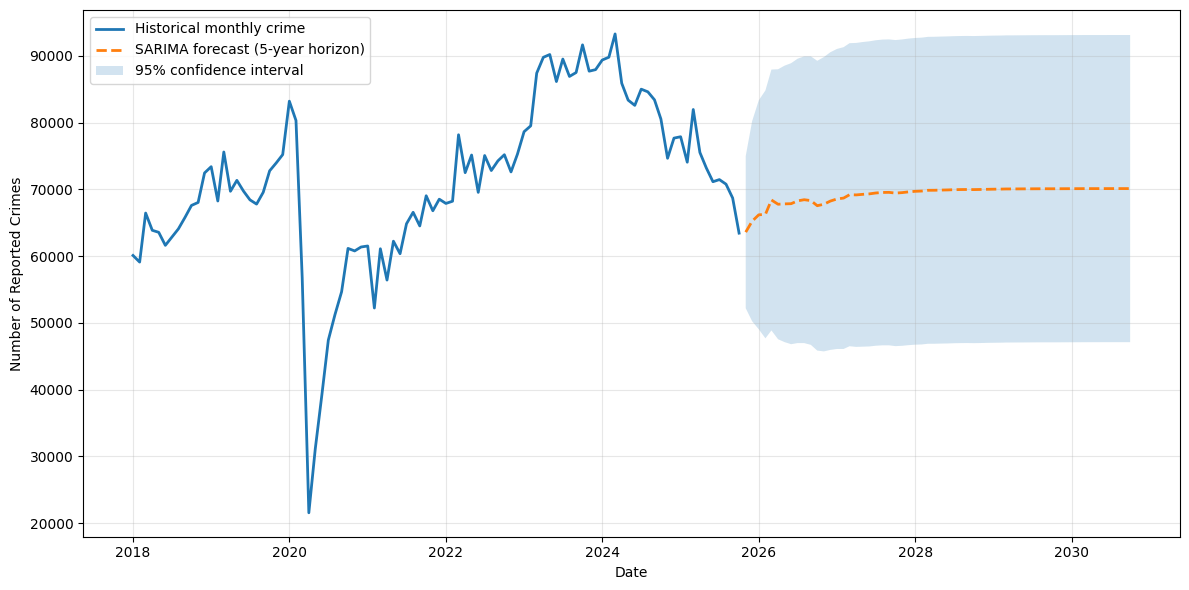

In [32]:
# =========================================
# Figure 1: Monthly Reported Crime in Peru
# Historical Series and SARIMA Projection
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 1) Load data
# -----------------------------
FILE = "/Users/karlavega/Proyectos/Colaborativos/Forest_Peru/colapso_con_ubigeo_reniec/denuncias_mensuales.xlsx"

df = pd.read_excel(FILE)

df["date"] = pd.to_datetime(
    df["ANIO"].astype(str) + "-" + df["MES"].astype(int).astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

df = df.dropna(subset=["date"])

# Aggregate monthly crime
ts = (
    df.groupby("date")["cantidad"]
      .sum()
      .asfreq("MS")
      .fillna(0)
      .astype(float)
)

# -----------------------------
# 2) Estimate SARIMA model
# -----------------------------
order = (1, 0, 0)
seasonal_order = (1, 0, 0, 12)

model = SARIMAX(
    ts,
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True
)

res = model.fit(disp=False)

# -----------------------------
# 3) Forecast (5 years = 60 months)
# -----------------------------
HORIZON = 60

forecast = res.get_forecast(steps=HORIZON)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

forecast_df = pd.DataFrame({
    "forecast": forecast_mean,
    "lower_ci": conf_int.iloc[:, 0],
    "upper_ci": conf_int.iloc[:, 1]
}).clip(lower=0)

# -----------------------------
# 4) Plot Figure
# -----------------------------
plt.figure(figsize=(12,6))

# Historical
plt.plot(ts.index, ts.values,
         label="Historical monthly crime",
         linewidth=2)

# Forecast
plt.plot(forecast_df.index,
         forecast_df["forecast"],
         linestyle="--",
         linewidth=2,
         label="SARIMA forecast (5-year horizon)")

# Confidence interval
plt.fill_between(
    forecast_df.index,
    forecast_df["lower_ci"],
    forecast_df["upper_ci"],
    alpha=0.2,
    label="95% confidence interval"
)



plt.xlabel("Date")
plt.ylabel("Number of Reported Crimes")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save high-resolution figure
plt.savefig("Figure1_MonthlyCrime_SARIMA.png", dpi=300)
plt.show()
